In [1]:
import pandas as pd
#import modin.pandas as pd
#import ray
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
sns.set(style='whitegrid',font_scale=2)
import os
import pickle
import time
os.chdir(os.getcwd())


## Read the data

In [2]:
#ae=pd.read_csv('../data/ttp_ae_standardised_with_time.csv',low_memory=False,index_col=0)
#ce=pd.read_csv('../data/ttp_ce_standardised_with_time.csv',low_memory=False,index_col=0)
#cm=pd.read_csv('../data/ttp_cm_standardised_with_time.csv',low_memory=False,index_col=0)
ce_mh=pd.read_csv('../data/out_ce_mh.csv.gz',low_memory=False,index_col=0)
cm_mh=pd.read_csv('../data/out_cm_mh.csv.gz',low_memory=False,index_col=0)
mh=pd.read_csv('../data/out_mh.csv.gz',low_memory=False,index_col=0).reset_index()


In [11]:
mh.columns#['MHOCCUR']

Index(['STUDYID', 'DOMAIN', 'USUBJID', 'MHSEQ', 'MHTERM', 'MHDECOD', 'MHHLT',
       'MHCAT', 'MHBODSYS', 'MHTOXGR', 'EPOCH', 'MHDY', 'MHSTDY', 'MHENDY',
       'MHENRTPT', 'MHENTPT', 'STSTUDMO', 'ENSTUDMO', 'STSTUDYR', 'ENSTUDYR',
       'STD_MHTERM'],
      dtype='object')

In [14]:
mh['MHHLT'].dropna()

11957                      TACHYCARDIA
11958                      TACHYCARDIA
11960                     HAEMORRHOIDS
11961                     PEPTIC ULCER
11962                     PEPTIC ULCER
                     ...              
12340                     HAEMORRHOIDS
12342    RESPIRATORY TRACT HAEMORRHAGE
12343    RESPIRATORY TRACT HAEMORRHAGE
12347                             RASH
12349                             RASH
Name: MHHLT, Length: 92, dtype: object

## Collect all standardised terms into one column ('ALL_TERMS')

In [3]:
all=pd.concat([mh[['STUDYID','USUBJID','STD_MHTERM']],ce_mh[['STUDYID','USUBJID','STD_CETERM']],cm_mh[['STUDYID','USUBJID','STD_CMINDC']]],ignore_index=True)

all_terms=all[~all['STD_MHTERM'].isna()]['STD_MHTERM'].tolist() + \
                    all[~all['STD_CETERM'].isna()]['STD_CETERM'].tolist() +\
                    all[~all['STD_CMINDC'].isna()]['STD_CMINDC'].tolist()                    
all['ALL_TERMS']=all_terms
all['ALL_TERMS']=all['ALL_TERMS'].replace({r'\.':'',';':'',r'\.':''},regex=True)
all['ALL_STD_TERMS']=all['ALL_TERMS']

## Introduce column to keep track how many times a cell has been used to extract data from. 
#  i.e. cell has 'HIGH ALP, GGT' then 2 pieces of information will be extracted in 2 newly created cells 
#  (one for HIGH ALP and one for HIGH GGT) -> this way the original cell is redundant -> can be filtered and dropped
all['NUM_OF_TIMES_USED_FOR_STANDARDISATION']=0

all=all.drop_duplicates()

In [5]:
a=all['ALL_TERMS'].value_counts()

## Refine standardisation of some common terms 

In [6]:
yes=[r'ALP|ALK']
yes2=[r'']
no=[r'Q|PAL|OP|STIF|BLUR']
all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]['ALL_TERMS'].value_counts()#.index.tolist()


ALL_TERMS
HIGH ALKALINE PHOSPHATASE      4
RAISED ALK PHOS                2
HIGH ALK PHOS                  1
RAISED ALK PHOS, GGT           1
HIGH ALK PHOS, GGT, ALT        1
HIGH ALP, GGT                  1
RAISED ALKALINE PHOSPHATASE    1
HIGH ALP                       1
RAISED ALP                     1
Name: count, dtype: int64

In [7]:
yes=[r'ALT']
yes2=[r'HI']
no=[r'Q|ALTER']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
add_df=all.loc[d.index,:]
add_df['ALL_STD_TERMS']='ELEVATED ALT'
all=all.append(add_df)
###---------------------------
yes=[r'ALP|ALK']
yes2=[r'']
no=[r'Q|PAL|OP|STIF|BLUR']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1

add_df=all.loc[d.index,:]
add_df['ALL_STD_TERMS']='ELEVATED ALP'
all=all.append(add_df)
###---------------------------
yes=[r'GGT']
yes2=[r'']
no=[r'ELE']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1

add_df=all.loc[d.index,:]
add_df['ALL_STD_TERMS']='ELEVATED GGT'
all=all.append(add_df)
###---------------------------
yes=[r'GAM']
yes2=[r'']
no=[r'Q']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='ELEVATED GGT'

###---------------------------
yes=[r'DIAR']
yes2=[r'']
no=[r'PREV|MIL']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1 
all.loc[d.index,'ALL_STD_TERMS']='DIARRHEA'
###---------------------------
yes=[r'MALAI']
yes2=[r'']
no=[r'q']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'ALL_STD_TERMS']='FEELING UNWELL'
###---------------------------
yes=[r'HYPERT']
yes2=[r'']
no=[r'ROI']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='HYPERTENSION'
###---------------------------
yes=[r'ANE']
yes2=[r'']
no=[r'Q|EAR|TYM']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='ANAEMIA'
###---------------------------
yes=[r'DIAB']
yes2=[r'']
no=[r'Q|RE']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1 
all.loc[d.index,'ALL_STD_TERMS']='DIABETES'
###---------------------------

yes=[r'HIV']
yes2=[r'']
no=[r'Q|R']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='HIV'
###---------------------------
yes=[r'APE']
yes2=[r'']
no=[r'Q|CREP|X|Y']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='LOSS OF APPETITE'
###---------------------------
yes=[r'PTYS|BLO']
yes2=[r'SP']
no=[r'q']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='HAEMOPTYSIS'
###---------------------------
yes=[r'WEIG']
yes2=[r'']
no=[r'q']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='WEIGHT LOSS'
###---------------------------

yes=[r'BREATH']
yes2=[r'SHO']
no=[r'q']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='DYSPNEA'
###---------------------------
yes=[r'FEVER']
yes2=[r'']
no=[r'RH|HAY|ENT|TYPH']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='FEVER'
###---------------------------
yes=[r'CHEST']
yes2=[r'PAI']
no=[r'Q']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='CHEST PAIN'
###---------------------------
yes=[r'RESPIRATORY TRACT']
yes2=[r'']
no=[r'Q']
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='RESPIRATORY TRACT INFECTION'
###---------------------------

yes=[r'PUPIL DI']
yes2=[r'']
no=[r"z"]
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='PUPIL DILATION'
###---------------------------
yes=[r'RESPIRATORY ABNORM']
yes2=[r'']
no=[r"z"]
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='RESPIRATORY ABNORMALITIES'
###---------------------------
yes=[r'FATIGUE|FATIQUE']
yes2=[r'']
no=[r"z"]
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='WEAKNESS'
###---------------------------
yes=[r'SWEAT']
yes2=[r'']
no=[r"z"]
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='SWEAT'
###---------------------------
yes=[r'MDR']
yes2=[r'FLO|FLUO']
no=[r"z"]
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='MDR-TB WITH FLUOROQUINOLONE RESISTANCE'

xdr_df=all.loc[d.index,:]
xdr_df['ALL_STD_TERMS']='XDR-TB'
all=all.append(xdr_df)

###---------------------------
yes=[r'MDR']
yes2=[r'FLO|FLUO']
no=[r"XDR"]
d=all[(all['ALL_TERMS'].str.contains('|'.join(yes),na=False))&(all['ALL_TERMS'].str.contains('|'.join(yes2),na=False))&
                            (~all['ALL_TERMS'].str.contains('|'.join(no),na=False))]

all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']=all.loc[d.index,'NUM_OF_TIMES_USED_FOR_STANDARDISATION']+1
all.loc[d.index,'ALL_STD_TERMS']='MDR-TB WITH FLUOROQUINOLONE RESISTANCE'

## Drop duplicates and rowd that have are redundant as their information has been extracted into new rows 
all=all.drop_duplicates()
all=all[all['NUM_OF_TIMES_USED_FOR_STANDARDISATION']<2]

AttributeError: 'DataFrame' object has no attribute 'append'

## 

## Create dataframe with patient IDs as rows and standardised terms as columns. If patient has a term in their medical history, it is indicated with a 1
- ### Filter for medical terms that are uncommon among the patients 

In [7]:
mh_std=pd.DataFrame(index=all['USUBJID'].unique(),columns=all['ALL_STD_TERMS'].unique().tolist()+['STUDYID'])

for pat_id,pat_df in all.groupby(by=['USUBJID']):
    std_terms=pat_df['ALL_STD_TERMS'].unique()
    mh_std.loc[pat_id,pat_df['ALL_STD_TERMS'].unique()]=1
    mh_std.loc[pat_id,'STUDYID']=pat_df['STUDYID'].unique()[0]

### Filter for common terms -> some terms are frequent in the medical history, some are rare
##  Set a threshold to keep only medical terms that are recorder in a minimum number of patients
terms_with_freq=all['ALL_STD_TERMS'].value_counts()
threshold=1
terms_to_keep=terms_with_freq[terms_with_freq>threshold].index.tolist() + ['STUDYID']
print('Dataframe shape before filtering: ', mh_std.shape)

## Drop medical terms that are below the threshold
mh_std_filt=mh_std.loc[:,mh_std.columns.isin(terms_to_keep)].dropna(how='all',axis=0)
print('Dataframe shape after filtering for terms occuring in more then ' + str(threshold) + ' patients: ', mh_std.shape)

/var/folders/0_/_m74rlq93855zphvhkg3qkhh19_hwl/T/ipykernel_27995/3411022893.py:3: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for pat_id,pat_df in all.groupby(by=['USUBJID']):


Dataframe shape before filtering:  (2457, 1491)
Dataframe shape after filtering for terms occuring in more then 1 patients:  (2457, 1491)


## Visualise the patients as a PCA and clustermap

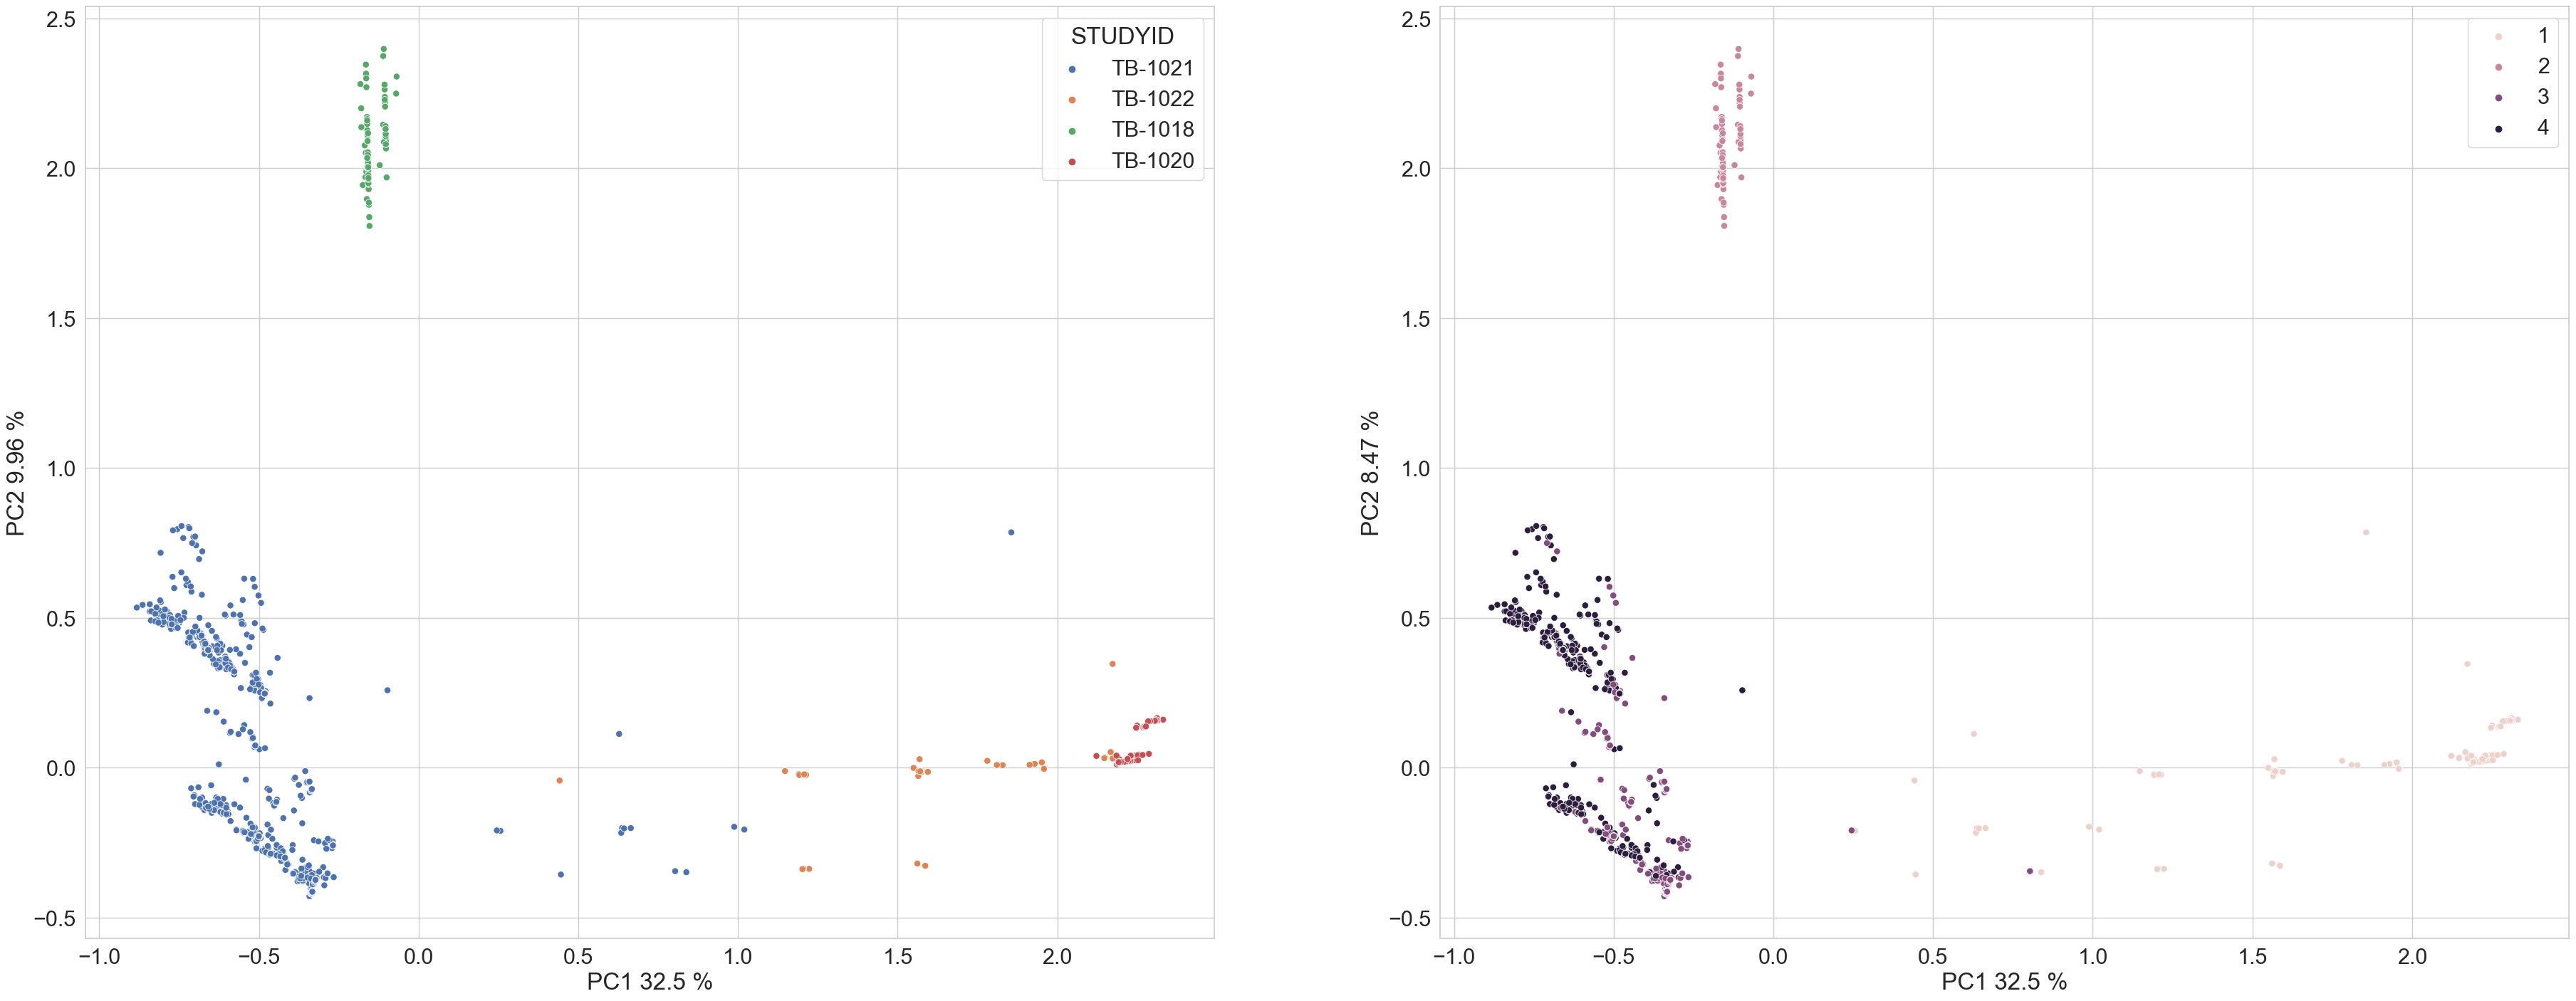

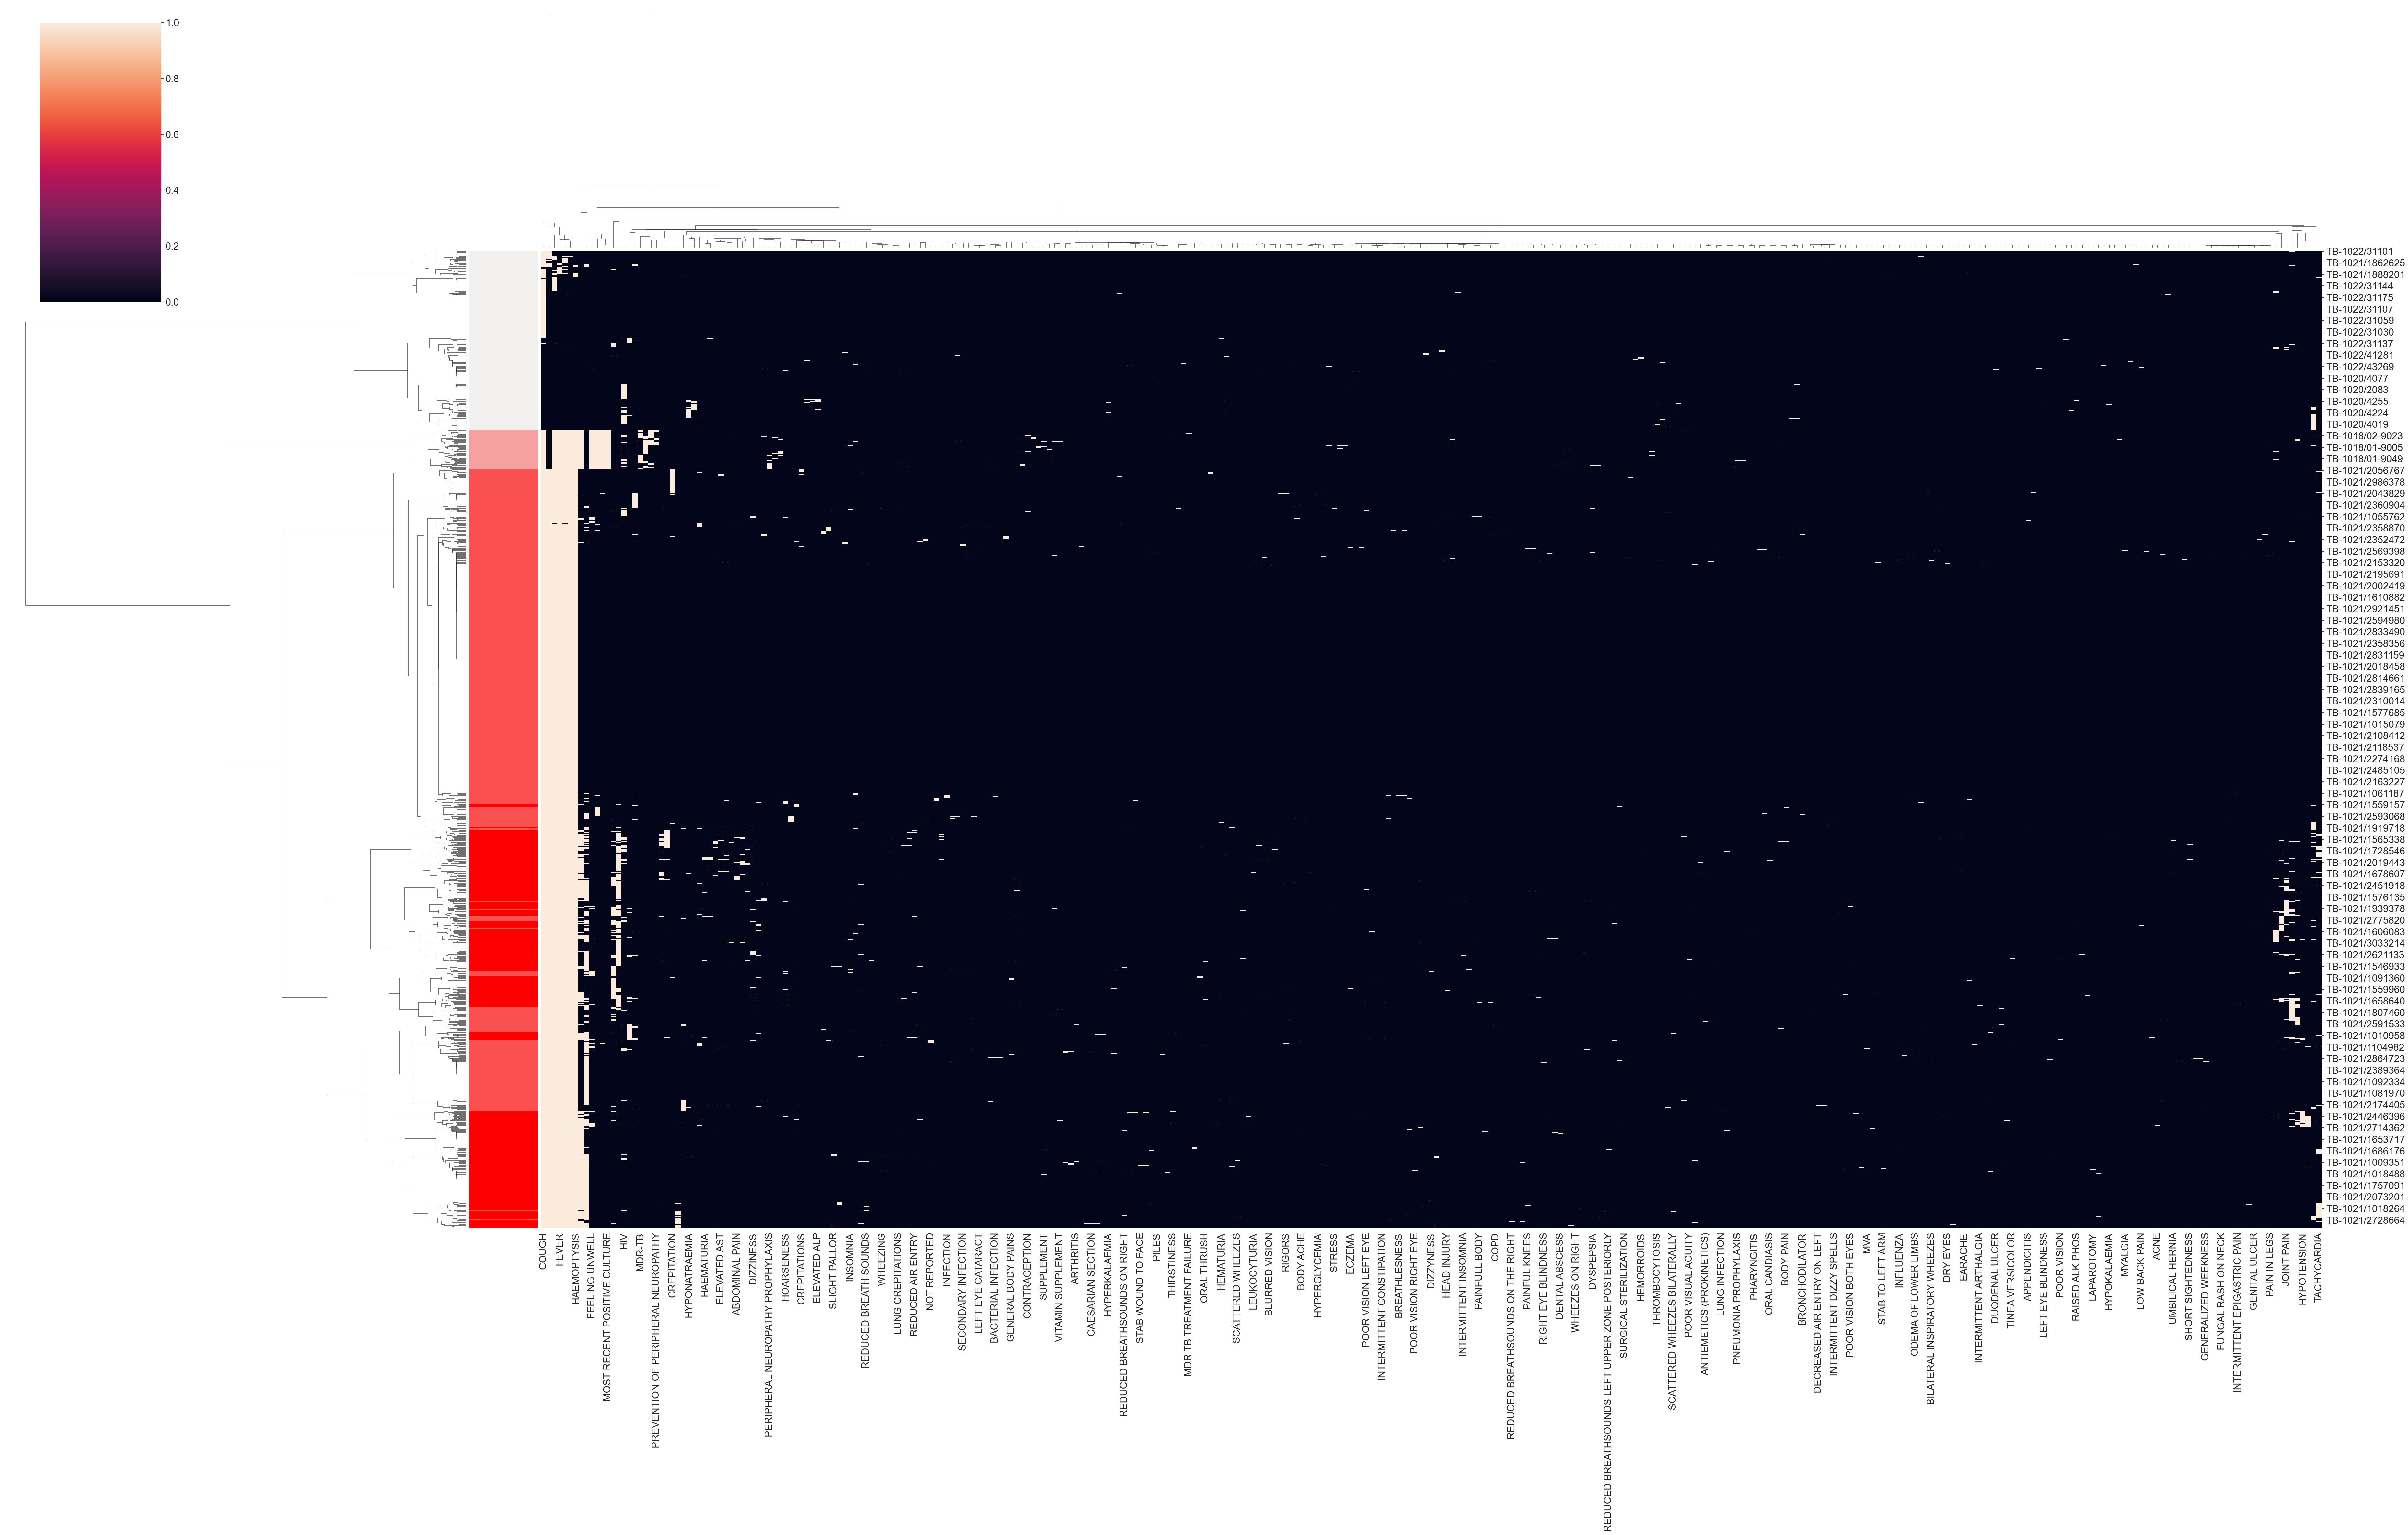

In [8]:
from sklearn.decomposition import PCA
from scipy.spatial import distance
from scipy.cluster import hierarchy

### Calculate PCA
pca = PCA(n_components=3)
data=mh_std_filt.loc[:,~mh_std_filt.columns.str.contains('STUDYID')].fillna(0)
pca_features = pca.fit_transform(data)

pca_df = pd.DataFrame(data=pca_features,columns=['PC1', 'PC2','PC3'])
pca_df['STUDYID']=mh_std['STUDYID'].values
fig,ax=plt.subplots(1,2,figsize=(45,17))

## Get hierachical clustering clusters
dist_metric='euclidean'
linkage_name='ward'
clust_num=4
linkage=hierarchy.linkage(distance.pdist(data,metric=dist_metric), method=linkage_name)
clusters=hierarchy.fcluster(linkage,clust_num,'maxclust')

## Plot PCA
sns.scatterplot(data=pca_df,x='PC1',y='PC2',ax=ax[0],hue='STUDYID',s=45)
ax[0].set_xlabel('PC1 ' + str(round(100*pca.explained_variance_ratio_[0],2)) +' %')
ax[0].set_ylabel('PC2 ' + str(round(100*pca.explained_variance_ratio_[1],2))+ ' %')

sns.scatterplot(data=pca_df,x='PC1',y='PC2',ax=ax[1],hue=clusters,s=45)
ax[1].set_xlabel('PC1 ' + str(round(100*pca.explained_variance_ratio_[0],2)) +' %')
ax[1].set_ylabel('PC2 ' + str(round(100*pca.explained_variance_ratio_[2],2))+ ' %')
#ax[1].legend().set_visible(False)


## PLot custermap of mh terms
colour_pal = sns.light_palette('red', clust_num)
lut = dict(zip(set(clusters), colour_pal))
clusters_df=pd.Series(clusters).to_frame()
clusters_df.columns=['Clusters']
row_colors=clusters_df['Clusters'].map(lut)

sns.clustermap(data,figsize=(75, 48), method=linkage_name,metric=dist_metric,row_colors=row_colors.values)

## Save standardised mh dataframe

In [9]:
all.to_csv('../data/out_mh_standardised.csv.gz',compression='gzip')
mh_std.to_csv('../data/out_mh_standardised_expanded.csv.gz',compression='gzip')

In [11]:
a=mh_std.loc[:,~mh_std.columns.str.contains('STUDYID')]
a.loc[:,a.sum()>10]

,HYPERTENSION,DIABETES,COUGH,SWEAT,WEIGHT LOSS,HIV,UVULECTOMY,ASTHMA,CHEST PAIN,DYSPNEA,...,SEVERE THIRST,MOST RECENT POSITIVE CULTURE,ELEVATED GGT,ANTIBIOTIC,XDR-TB,MDR-TB,OPHTHALMOLOGY EXAMINATION,PUPIL DILATION,PERIPHERAL NEUROPATHY PROPHYLAXIS,PREVENTION OF PERIPHERAL NEUROPATHY
TB-1021/2468433,NaN,NaN,1,1,1,NaN,NaN,NaN,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TB-1021/1015985,NaN,NaN,1,1,1,NaN,NaN,NaN,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TB-1021/1058012,NaN,NaN,1,1,1,NaN,NaN,NaN,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TB-1021/1008903,1,NaN,1,1,1,NaN,NaN,NaN,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TB-1021/1608581,NaN,NaN,1,1,1,NaN,NaN,NaN,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TB-1020/6087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TB-1021/2127946,NaN,NaN,1,1,1,NaN,NaN,NaN,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TB-1022/21129,NaN,NaN,1,1,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TB-1022/21173,NaN,NaN,1,1,NaN,NaN,NaN,NaN,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
